In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.dummy import DummyClassifier
import imblearn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve

random_state=809

# 1) Issue with Unalanced Datasets
## Load a dataset

In [2]:
n_features, n_informative, n_redundant = 10, 7, 3
n_samples = 10000
X, y = make_classification(n_samples=n_samples, 
                           n_features=n_features, 
                           n_informative = n_informative, 
                           n_redundant = n_redundant,
                           random_state=random_state)

# Create the Out-Of-Sample dataset
test_size = 0.3
X_IS, X_OOS, y_IS, y_OOS = train_test_split(X, y, test_size=test_size, random_state=random_state)

# Put into a DataFrame
variables = [f"Variable {x+1}" for x in range(n_features)] 
df = pd.DataFrame(X_IS, columns = variables)
df['Outcome_Variable'] = y_IS
df

,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9,Variable 10,Outcome_Variable
0,-1.017048,0.368111,-0.034782,3.096375,-0.003820,-1.587847,-0.789503,1.110302,4.275386,1.862898,1
1,5.907686,-4.839517,-1.600878,-1.670406,-1.778869,3.576057,-3.121417,-2.261760,0.091485,0.744195,1
2,-2.430486,-0.272484,0.426456,-0.422785,2.525640,-2.173406,3.918450,-3.604272,-0.337458,-0.250380,1
3,1.901679,1.157343,-1.919196,1.204595,-2.478752,-0.282100,0.357719,4.344617,0.901711,5.507749,0
4,-3.756753,-2.324807,-5.650626,2.720018,4.477198,2.004362,2.032145,-9.598979,0.953263,-2.839749,0
...,...,...,...,...,...,...,...,...,...,...,...
6995,0.481778,0.905078,-0.341549,-2.715238,1.972847,-3.344976,3.342236,-2.959179,-0.098625,2.091298,0
6996,-4.754748,-5.257062,-3.128796,3.466747,3.700493,3.723943,3.290744,-9.173187,-1.024790,-4.415626,0
6997,1.574252,-1.716183,-0.255075,-0.352128,1.184284,-0.331993,0.188739,-2.479080,1.779192,1.039926,1
6998,-0.594620,-4.315869,-2.927567,2.276931,0.680314,1.415588,-1.104594,-6.418471,2.588826,-1.599594,1


## Creating an Imbalanced Dataset

In [3]:
fraction_of_positives = 0.05

# Create two datasets with thsoe of class 0 and 1
df_0 = df[df['Outcome_Variable']==0]
df_1 = df[df['Outcome_Variable']==1]

# Create the imbalanced dataset
df_imbalanced = df_0.append(df_1.sample(frac=fraction_of_positives))

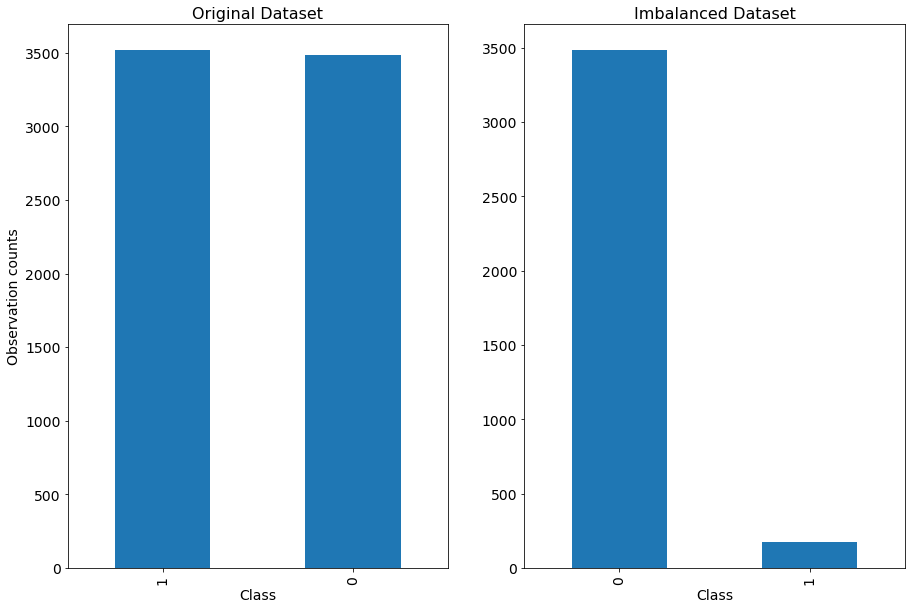

In [4]:
# Plot of the outcome variable in both datasets
fig, (ax, ax1) = plt.subplots(figsize=(15,10), ncols = 2)
df['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
df_imbalanced['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax1, fontsize=14)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
ax1.set_xlabel('Class', fontsize=14)
ax.set_title('Original Dataset', fontsize=16)
ax1.set_title('Imbalanced Dataset', fontsize=16)
plt.show()

## Train a classifier on both Datasets

In [5]:
model_balanced = LogisticRegression()
model_balanced.fit(df[variables], df['Outcome_Variable'])
    
model_imbalanced = LogisticRegression()
model_imbalanced.fit(df_imbalanced[variables], df_imbalanced['Outcome_Variable'])

LogisticRegression()

## ROC and PR curves for the balanced dataset

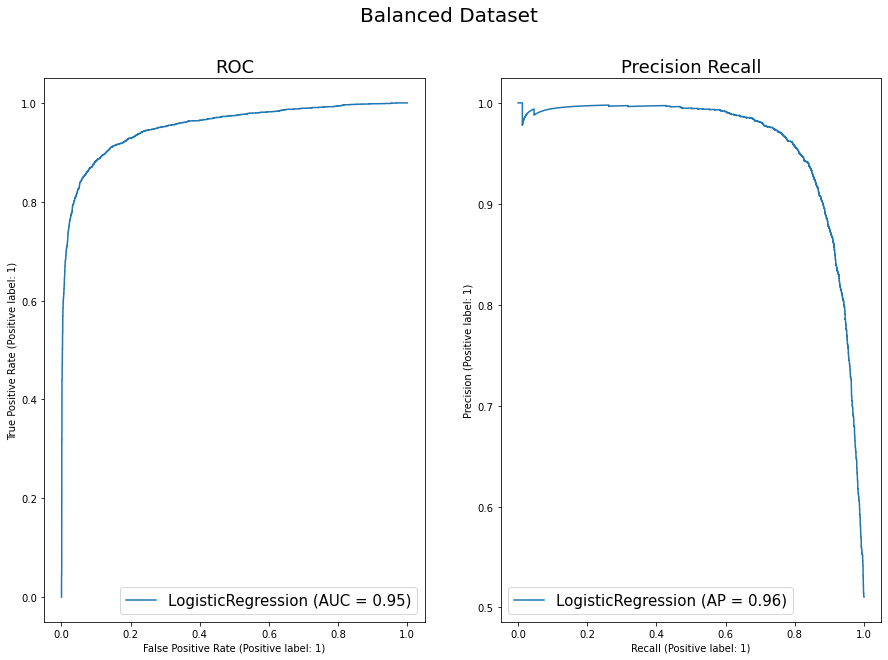

In [6]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(15,10))
plot_roc_curve(model_balanced, df[variables], df['Outcome_Variable'], ax=ax)  
plot_precision_recall_curve(model_balanced, df[variables], df['Outcome_Variable'], ax=ax1)
ax.set_title('ROC', fontsize=18)
ax1.set_title('Precision Recall', fontsize=18)
ax.legend(fontsize=15)
ax1.legend(fontsize=15)
plt.suptitle('Balanced Dataset', fontsize=20)
plt.show()

## ROC and PR curves for the imbalanced dataset

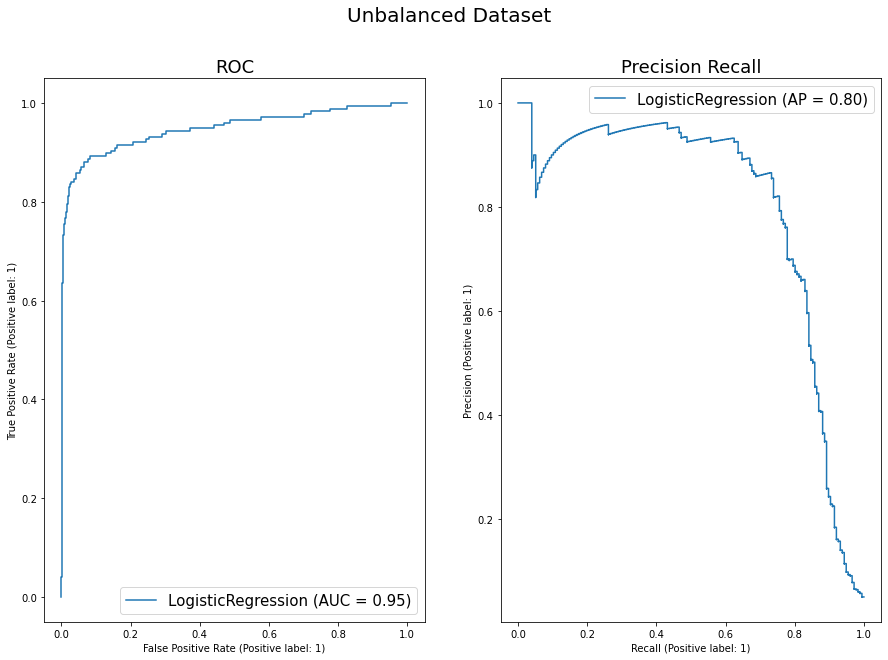

In [7]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(15,10))
plot_roc_curve(model_imbalanced, df_imbalanced[variables], df_imbalanced['Outcome_Variable'], ax=ax)  
plot_precision_recall_curve(model_imbalanced, df_imbalanced[variables], df_imbalanced['Outcome_Variable'], ax=ax1)
ax.set_title('ROC', fontsize=18)
ax1.set_title('Precision Recall', fontsize=18)
ax.legend(fontsize=15)
ax1.legend(fontsize=15)
plt.suptitle('Unbalanced Dataset', fontsize=20)
plt.show()

### In the case of the unbalanced dataset, the Average Precision (AP) is lower 

Average precision (AP) is the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$AP = \sum_n \frac{(R_n - R_{n-1})}{P_n}$ 

Where: $R_n$ and $P_n$ are the precision and recall at the $n$-th threshold



# 2) Dealing with Imbalanced Datasets

In [8]:
n_features, n_informative, n_redundant = 2, 2, 0
n_samples = 6000
X, y = make_classification(n_samples=n_samples, 
                           n_features=n_features, 
                           n_informative = n_informative, 
                           n_redundant = n_redundant,
                           random_state=random_state, 
                           weights = [0.8, 0.2])

# Putting it into a dataframe
variables = [f"Variable {x+1}" for x in range(n_features)] 
df_imbalanced = pd.DataFrame(X, columns = variables)
df_imbalanced['Outcome_Variable'] = y

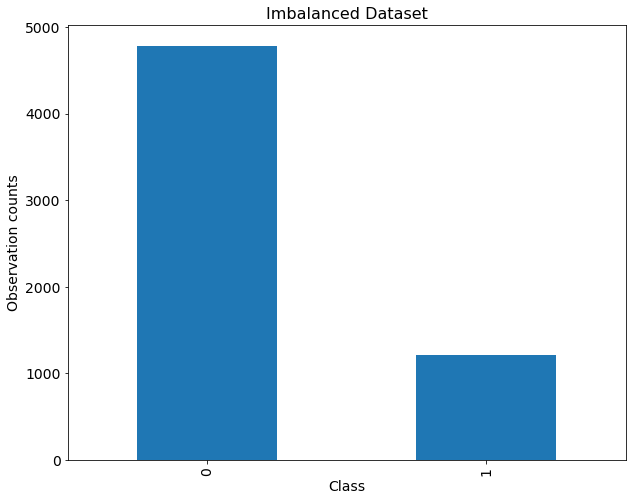

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
df_imbalanced['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
ax.set_title('Imbalanced Dataset', fontsize=16)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
plt.show()

## 2) a) Oversampling

In [10]:
oversample = imblearn.over_sampling .RandomOverSampler(sampling_strategy='minority')

variables = [f'Variable {x}' for x in range(1, 3)]
oversample_x, oversample_y = oversample.fit_sample(df_imbalanced[variables], df_imbalanced['Outcome_Variable'])

df_oversampled = pd.DataFrame(oversample_x, columns = variables)
df_oversampled['Outcome_Variable'] = oversample_y
df_oversampled

,Variable 1,Variable 2,Outcome_Variable
0,0.358199,2.225574,0
1,-0.268371,-0.304072,0
2,1.865766,0.923186,0
3,-1.080080,-1.115966,0
4,-0.662446,1.087722,0
...,...,...,...
9569,0.705998,0.628298,1
9570,0.090930,-1.106379,1
9571,-0.412727,1.679966,1
9572,1.180228,1.038224,1


### What Happened?

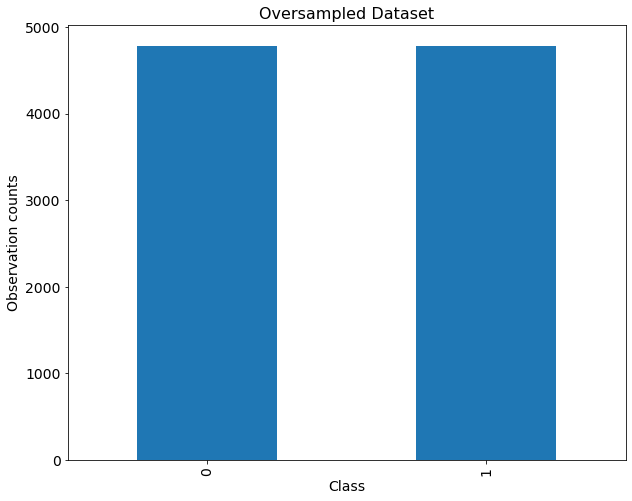

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
df_oversampled['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
ax.set_title('Oversampled Dataset', fontsize=16)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
plt.show()

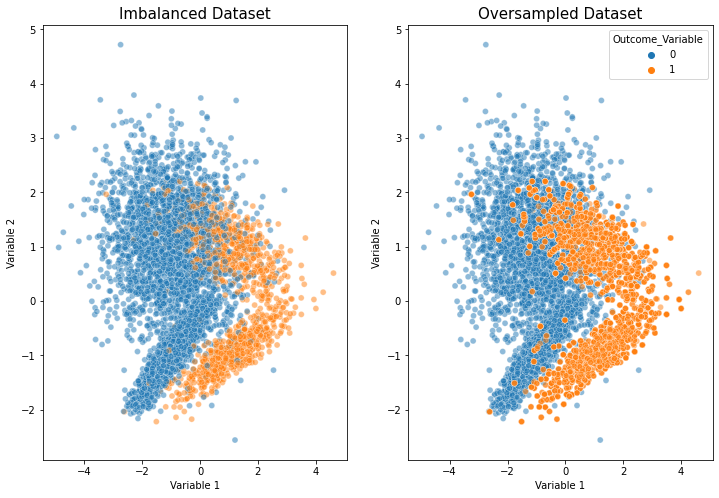

In [12]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(12,8))
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_imbalanced, ax=ax, hue='Outcome_Variable', legend=False, alpha=0.5)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_oversampled, ax=ax1, hue='Outcome_Variable', alpha=0.5)
ax.set_title('Imbalanced Dataset', fontsize=15)
ax1.set_title('Oversampled Dataset', fontsize=15)
plt.show()

## 2) b) Undersampling

In [13]:
undersampler = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority')

variables = [f'Variable {x}' for x in range(1, 3)]
undersample_x, undersample_y = undersampler.fit_sample(df_imbalanced[variables], df_imbalanced['Outcome_Variable'])

df_undersampled = pd.DataFrame(undersample_x, columns = variables)
df_undersampled['Outcome_Variable'] = undersample_y
df_undersampled

,Variable 1,Variable 2,Outcome_Variable
0,-1.068729,-1.002054,0
1,0.521134,2.175274,0
2,0.266326,0.834019,0
3,-0.578260,1.873541,0
4,-0.908493,-1.022822,0
...,...,...,...
2421,0.326079,0.588997,1
2422,2.392147,0.775177,1
2423,2.205659,0.368222,1
2424,2.668891,0.845996,1


### What Happened?

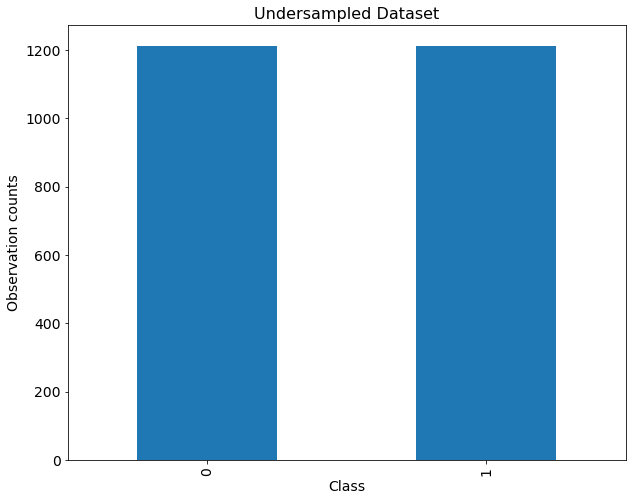

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
df_undersampled['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
ax.set_title('Undersampled Dataset', fontsize=16)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
plt.show()

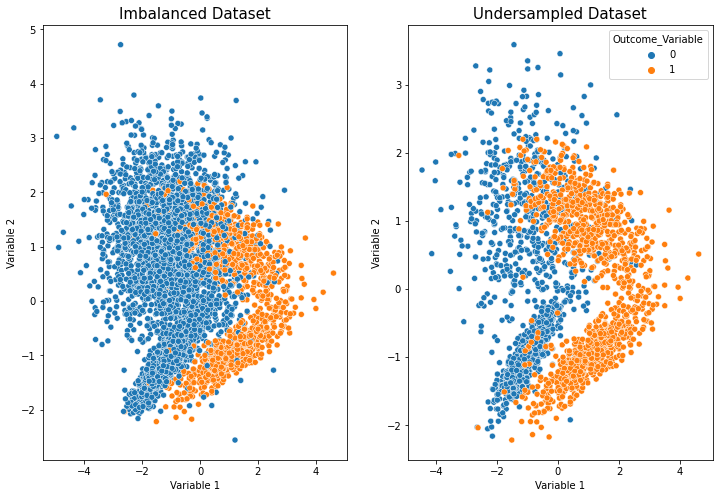

In [15]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(12,8))
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_imbalanced, ax=ax, hue='Outcome_Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_undersampled, ax=ax1, hue='Outcome_Variable')
ax.set_title('Imbalanced Dataset', fontsize=15)
ax1.set_title('Undersampled Dataset', fontsize=15)
plt.show()

## 2) c) SMOTE

In [16]:
smote_oversampler = imblearn.over_sampling.SMOTE()

variables = [f'Variable {x}' for x in range(1, 3)]
smote_x, smote_y = smote_oversampler.fit_sample(df_imbalanced[variables], df_imbalanced['Outcome_Variable'])

df_smote = pd.DataFrame(smote_x, columns = variables)
df_smote['Outcome_Variable'] = smote_y
df_smote

,Variable 1,Variable 2,Outcome_Variable
0,0.358199,2.225574,0
1,-0.268371,-0.304072,0
2,1.865766,0.923186,0
3,-1.080080,-1.115966,0
4,-0.662446,1.087722,0
...,...,...,...
9569,1.936526,0.994238,1
9570,1.310708,-0.996264,1
9571,-0.888370,-0.790902,1
9572,1.722561,1.180430,1


### What Happened?

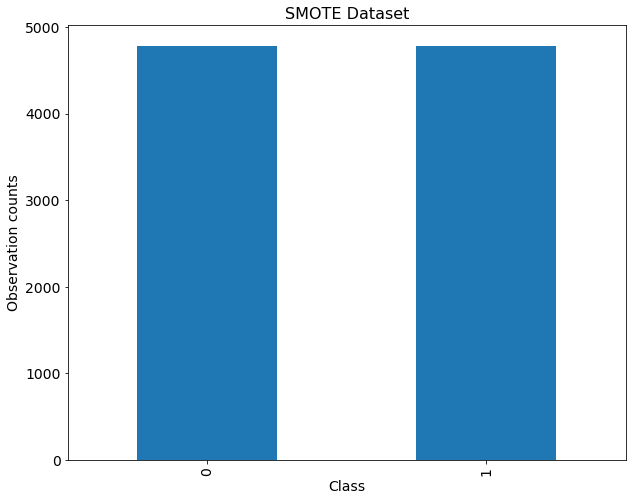

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
df_smote['Outcome_Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
ax.set_title('SMOTE Dataset', fontsize=16)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
plt.show()

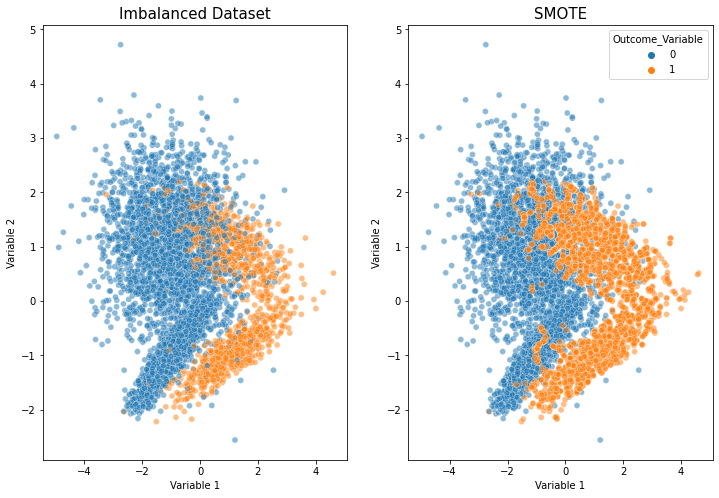

In [18]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(12,8))
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_imbalanced, ax=ax, hue='Outcome_Variable', legend=False, alpha=0.5)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote, ax=ax1, hue='Outcome_Variable', alpha=0.5)
ax.set_title('Imbalanced Dataset', fontsize=15)
ax1.set_title('SMOTE', fontsize=15)
plt.show()

## 2)d) SMOTE with more than 2 classes

In [19]:
n_features, n_informative, n_redundant = 3, 3, 0
n_samples = 1000
X, y = make_classification(n_samples=n_samples, 
                           n_features=n_features, 
                           n_informative = n_informative, 
                           n_redundant = n_redundant,
                           random_state=random_state, n_classes=3, 
                           weights = [0.7, 0.2, 0.1])


variables = [f"Variable {x+1}" for x in range(n_features)] 
df_imbalanced_2 = pd.DataFrame(X, columns = variables)
df_imbalanced_2['Outcome Variable'] = y

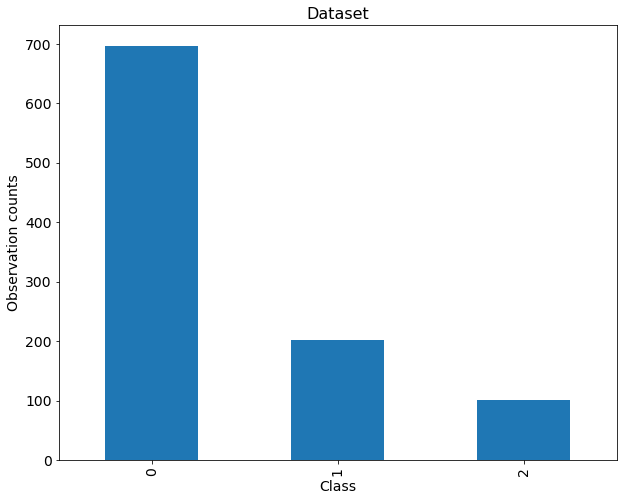

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
df_imbalanced_2['Outcome Variable'].value_counts().plot(kind='bar', ax=ax, fontsize=14)
ax.set_title('Dataset', fontsize=16)
ax.set_ylabel('Observation counts', fontsize=14)
ax.set_xlabel('Class', fontsize=14)
plt.show()

In [21]:
smote_oversampler = imblearn.over_sampling.SMOTE()
smote_x_2, smote_y_2 = smote_oversampler.fit_sample(X,  y)

df_smote_2 = pd.DataFrame(smote_x_2, columns = variables)
df_smote_2['Outcome Variable'] = smote_y_2

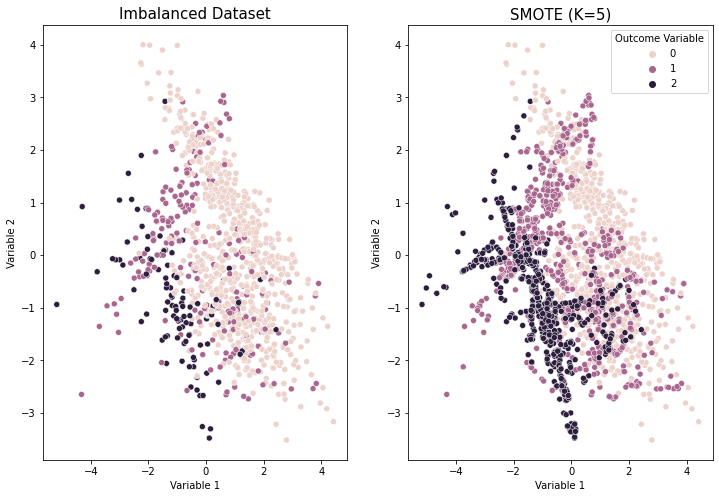

In [22]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(12,8))
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_imbalanced_2, ax=ax, hue='Outcome Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_2, ax=ax1, hue='Outcome Variable')
ax.set_title('Imbalanced Dataset', fontsize=15)
ax1.set_title('SMOTE (K=5)', fontsize=15)
plt.show()

## 2)e) SMOTE  - Selecting the number of Neighbors

In [23]:
def train_smote(X,  y, k_neighbors, random_state):
    smote_oversampler = imblearn.over_sampling.SMOTE(k_neighbors=k_neighbors, random_state=random_state)
    smote_x, smote_y = smote_oversampler.fit_sample(X,  y)
    df_smote = pd.DataFrame(smote_x, columns = variables)
    df_smote['Outcome Variable'] = smote_y
    return df_smote

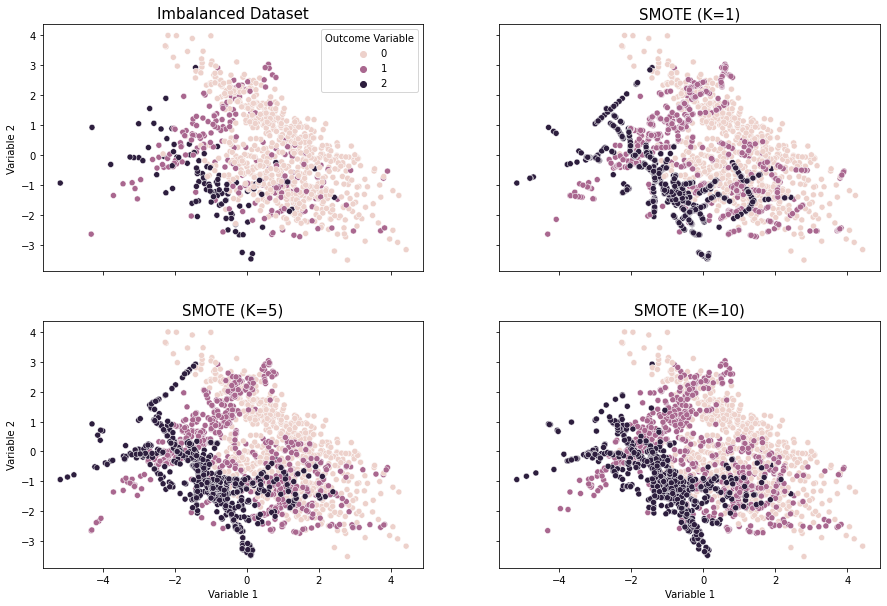

In [24]:
df_smote_k1 =  train_smote(X,  y, k_neighbors=1, random_state=random_state)
df_smote_k5 =  train_smote(X,  y, k_neighbors=5, random_state=random_state)
df_smote_k10 =  train_smote(X,  y, k_neighbors=10, random_state=random_state)

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(15,10), sharex=True, sharey=True)
ax = ax.flatten()
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_imbalanced_2, ax=ax[0], hue='Outcome Variable', legend=True)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k1, ax=ax[1], hue='Outcome Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k5, ax=ax[2], hue='Outcome Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k10, ax=ax[3], hue='Outcome Variable', legend=False)
ax[0].set_title('Imbalanced Dataset', fontsize=15)
ax[1].set_title('SMOTE (K=1)', fontsize=15)
ax[2].set_title('SMOTE (K=5)', fontsize=15)
ax[3].set_title('SMOTE (K=10)', fontsize=15)
plt.show()

### Where Randomness comes in

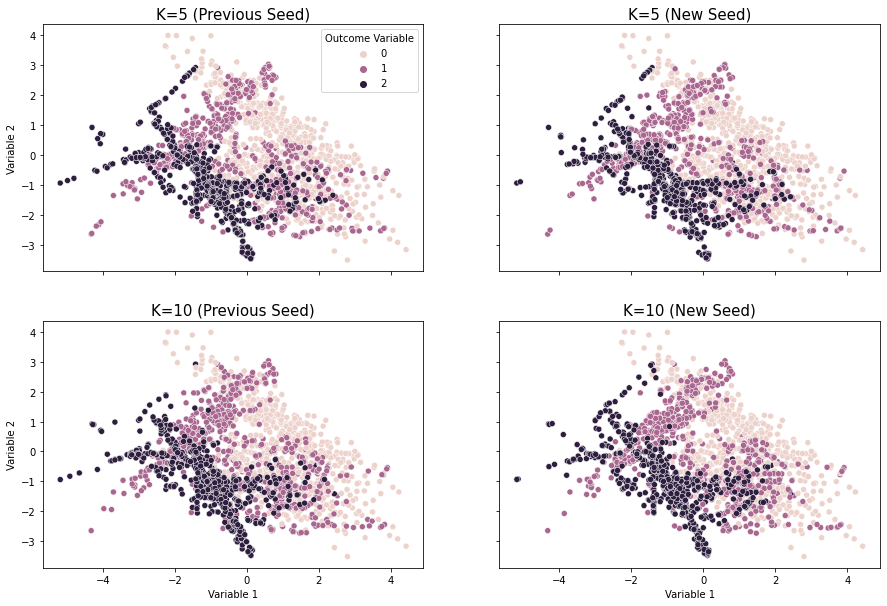

In [25]:
df_smote_k5_rand =  train_smote(X,  y, k_neighbors=5, random_state=1)
df_smote_k10_rand =  train_smote(X,  y, k_neighbors=10, random_state=1)

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(15,10), sharex=True, sharey=True)
ax = ax.flatten()
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k5, ax=ax[0], hue='Outcome Variable', legend=True)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k5_rand, ax=ax[1], hue='Outcome Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k10, ax=ax[2], hue='Outcome Variable', legend=False)
sns.scatterplot(x="Variable 1", y="Variable 2", data=df_smote_k10_rand, ax=ax[3], hue='Outcome Variable', legend=False)
ax[0].set_title('K=5 (Previous Seed)', fontsize=15)
ax[1].set_title('K=5 (New Seed)', fontsize=15)
ax[2].set_title('K=10 (Previous Seed)', fontsize=15)
ax[3].set_title('K=10 (New Seed)', fontsize=15)
plt.show()

# 3) The RIGHT way to SMOTE

In [26]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.pipeline import Pipeline

In [27]:
# Load An imbalanced dataset
n_features, n_informative, n_redundant = 4, 4, 0
n_samples = 7000
X, y = make_classification(n_samples=n_samples, 
                           n_features=n_features, 
                           n_informative = n_informative, 
                           n_redundant = n_redundant,
                           random_state=random_state, n_classes=2, 
                          weights = [0.9, 0.1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## 3)a) Test Without SMOTE, Using AP as a METRIC

In [28]:
# We Create a Pipeline to do three things to the training FOLDS:
#1- Apply a MinMax Scaler to the data
#2- Apply the KNN
pipeline = Pipeline(steps = [['scaler', MinMaxScaler()],
                                ['classifier', KNeighborsClassifier()]])

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
param_grid = {'classifier__n_neighbors': [20, 30, 40, 50, 75, 90, 100, 110, 125, 150, 175]}
grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=cv,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.8178742938345556
Test score: 0.8029669410182143


## 3)b) Test With SMOTE, Using AP as a METRIC


In [29]:
# We Create a Pipeline to do three things to the training FOLDS:
#1- Apply Smote to it
#2- Apply a MinMax Scaler to the data
#3- Apply the KNN
pipeline = imbpipeline(steps = [['smote', SMOTE(random_state=random_state)],
                                ['scaler', MinMaxScaler()],
                                ['classifier', KNeighborsClassifier()]])

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
param_grid = {'classifier__n_neighbors': [20, 30, 40, 50, 75, 90, 100, 110, 125, 150, 175]}
grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=cv,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.8278067163948514
Test score: 0.8157998064432217


## 3)c) Test Without SMOTE, Using AUC as a METRIC

In [30]:
pipeline = Pipeline(steps = [['scaler', MinMaxScaler()],
                                ['classifier', KNeighborsClassifier()]])

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
param_grid = {'classifier__n_neighbors': [20, 30, 40, 50, 75, 90, 100, 110, 125, 150, 175]}
grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=cv,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.9607695528409899
Test score: 0.9424727518690657


## 3)d) Test With SMOTE, Using AUC as a METRIC

In [31]:
pipeline = imbpipeline(steps = [['smote', SMOTE(random_state=11)],
                                ['scaler', MinMaxScaler()],
                                ['classifier', KNeighborsClassifier()]])

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
param_grid = {'classifier__n_neighbors': [20, 30, 40, 50, 75, 90, 100, 110, 125, 150, 175]}
grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=cv,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.9610773833834191
Test score: 0.9456651516005555


# 4) Optimizing SMOTE

In [32]:
# We Create a Pipeline to do three things to the training FOLDS:
#1- Apply Smote to it
#2- Apply a MinMax Scaler to the data
#3- Apply the KNN

# But here, we also optimize SMOTE
pipeline = imbpipeline(steps = [['smote', SMOTE(random_state=random_state)],
                                ['scaler', MinMaxScaler()],
                                ['classifier', KNeighborsClassifier()]])

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    
param_grid = {'smote__k_neighbors': [1, 2, 3, 4, 5, 10, 15, 20], 
              'classifier__n_neighbors': [20, 30, 40, 50, 75, 90, 100, 110, 125, 150, 175]}


grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=cv,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.8304133770186823
Test score: 0.8190025726481476


In [33]:
print(f"The best number of Neighbors for KNN is {grid_search.best_params_['classifier__n_neighbors']}")
print(f"The best number of Neighbors for SMOTE is {grid_search.best_params_['smote__k_neighbors']}")

The best number of Neighbors for KNN is 90
The best number of Neighbors for SMOTE is 1
